In [60]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew
from sklearn.preprocessing import QuantileTransformer
import matplotlib.pyplot as plt

簡単に実装できるものを取り上げてみる.
California Housing（カリフォルニアの住宅価格）データセットの世帯収入の中央値を利用

In [48]:
housing = fetch_california_housing()

In [49]:
x=housing.data[:,0]

まさに、右に裾を引いている

(array([2247., 7436., 6098., 2990., 1060.,  428.,  178.,   93.,   47.,
          63.]),
 array([ 0.4999 ,  1.94992,  3.39994,  4.84996,  6.29998,  7.75   ,
         9.20002, 10.65004, 12.10006, 13.55008, 15.0001 ]),
 <BarContainer object of 10 artists>)

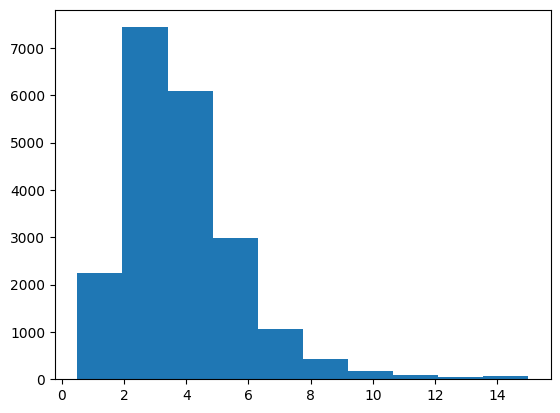

In [50]:
plt.hist(x)

1.2　非線形変換

(array([  97.,  534., 2032., 4091., 5367., 4654., 2572.,  883.,  283.,
         127.]),
 array([0.40539844, 0.64211809, 0.87883775, 1.1155574 , 1.35227705,
        1.58899671, 1.82571636, 2.06243601, 2.29915567, 2.53587532,
        2.77259497]),
 <BarContainer object of 10 artists>)

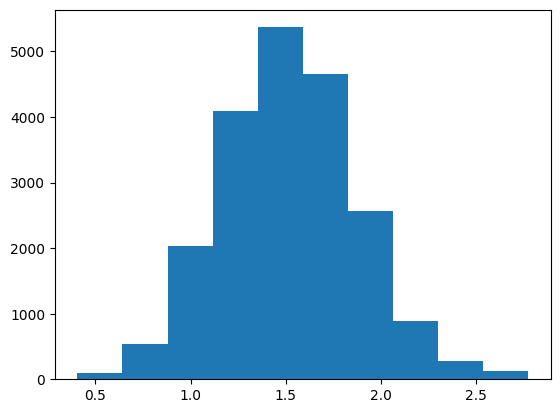

In [51]:
x_log = np.log(x + 1)
plt.hist(x_log)

RankGauss

(array([  12.,   10.,  398., 2672., 7289., 7148., 2718.,  344.,    0.,
          49.]),
 array([-5.19933758e+00, -4.15947007e+00, -3.11960255e+00, -2.07973503e+00,
        -1.03986752e+00,  4.89217555e-11,  1.03986752e+00,  2.07973503e+00,
         3.11960255e+00,  4.15947007e+00,  5.19933758e+00]),
 <BarContainer object of 10 artists>)

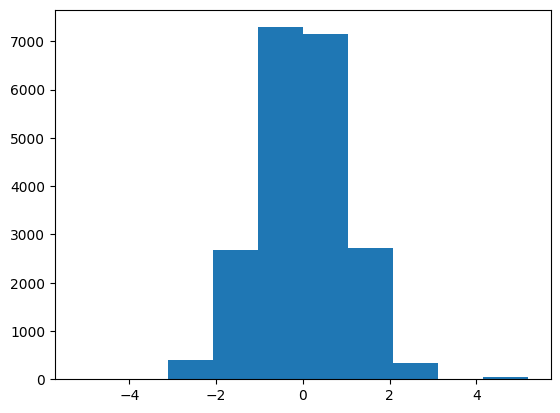

In [52]:
qt = QuantileTransformer(output_distribution='normal', random_state=42)
x_rankgauss_sku = qt.fit_transform(x.reshape(-1, 1)).flatten()
plt.hist(x_rankgauss_sku)

Box-Cox

(array([  38.,  175.,  721., 2527., 4666., 6005., 4153., 1757.,  451.,
         147.]),
 array([-3.80256788, -3.09132857, -2.38008926, -1.66884994, -0.95761063,
        -0.24637132,  0.464868  ,  1.17610731,  1.88734662,  2.59858593,
         3.30982525]),
 <BarContainer object of 10 artists>)

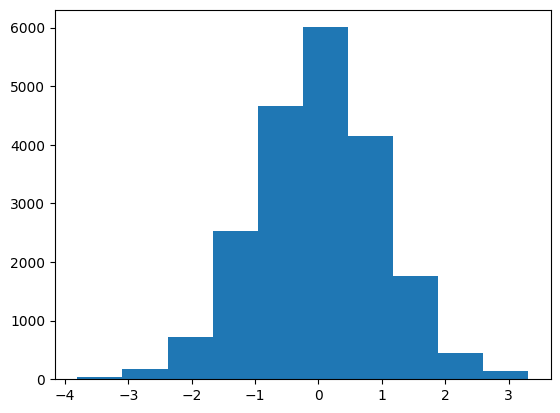

In [53]:
pt_bc = PowerTransformer(method='box-cox')
x_bc = pt_bc.fit_transform(x.reshape(-1, 1)).flatten()
plt.hist(x_bc)

(array([  62.,  298., 1165., 2847., 4678., 5322., 3848., 1749.,  503.,
         168.]),
 array([-3.4460848 , -2.78681917, -2.12755355, -1.46828792, -0.8090223 ,
        -0.14975667,  0.50950896,  1.16877458,  1.82804021,  2.48730583,
         3.14657146]),
 <BarContainer object of 10 artists>)

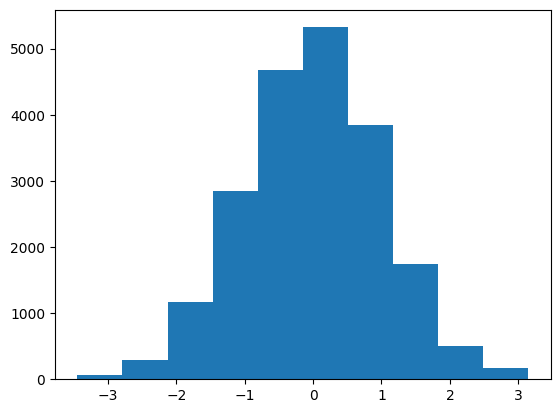

In [54]:
pt_yj = PowerTransformer(method='yeo-johnson')
x_yj = pt_yj.fit_transform(x.reshape(-1, 1)).flatten()
plt.hist(x_yj)

1.8 UMAP 適用

In [55]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import umap

In [56]:
digits = load_digits()
X, y = digits.data, digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap = reducer.fit_transform(X_scaled)


/home/popo/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [57]:
print(f"元の特徴量 X の形状: {X.shape}")       
print(f"UMAP変換後の X の形状: {X_umap.shape}")

元の特徴量 X の形状: (1797, 64)
UMAP変換後の X の形状: (1797, 2)


そんなに悪くない圧縮な気がする、
ただし、紫のところはいまいちな感じ
でも、64次元を２次元に変換してるので、こんなものな気がする。

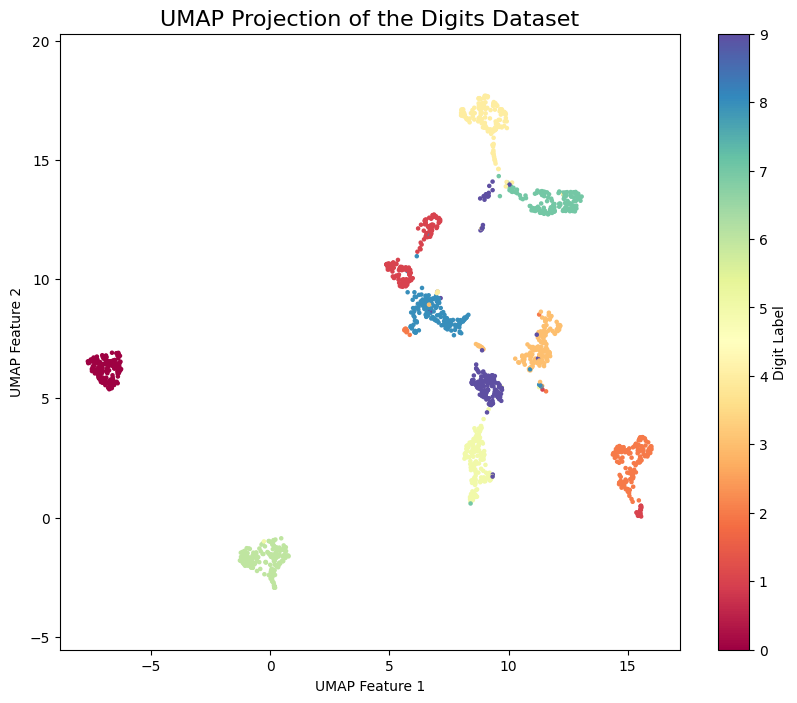

In [58]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='Spectral', s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(scatter, label='Digit Label')
plt.title('UMAP Projection of the Digits Dataset', fontsize=16)
plt.xlabel('UMAP Feature 1')
plt.ylabel('UMAP Feature 2')
plt.show()

2.1 簡単にAdversarial Validationの構築を行う

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb

In [77]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df_train_raw, df_test_raw = train_test_split(df, test_size=0.3, random_state=42)
df_train_raw = df_train_raw.copy()
df_test_raw = df_test_raw.copy()
df_train_raw['is_test'] = 0
df_test_raw['is_test'] = 1
df_adv = pd.concat([df_train_raw, df_test_raw], axis=0).reset_index(drop=True)
features = [col for col in df.columns if col not in ['is_test', 'MedHouseValue']]
X_adv = df_adv[features]
y_adv = df_adv['is_test']
X_tr, X_va, y_tr, y_va = train_test_split(
    X_adv, y_adv, test_size=0.3, random_state=999, stratify=y_adv
)



aucの結果から、分布は変化していないことが分かる

In [78]:
train_dataset = lgb.Dataset(X_tr, label=y_tr)
val_dataset = lgb.Dataset(X_va, label=y_va)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'verbosity': -1,
    'random_state': 42
}

model = lgb.train(
    params,
    train_dataset,
    valid_sets=[val_dataset],
    num_boost_round=200,
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 予測とAUCの算出
preds = model.predict(X_va)
auc_score = roc_auc_score(y_va, preds)
print(f"--- Adversarial Validation 結果 ---")
print(f"ROC-AUC Score: {auc_score:.4f}")

--- Adversarial Validation 結果 ---
ROC-AUC Score: 0.5067


In [86]:
importance = model.feature_importance(importance_type='gain')
df_importance = pd.DataFrame({'Feature': features, 'Gain': importance}).sort_values(by='Gain', ascending=False)
df_importance.head(10)

,Feature,Gain
5,AveOccup,51.644141
8,MedHouseVal,44.526510
7,Longitude,25.723280
3,AveBedrms,23.157910
2,AveRooms,21.938890
4,Population,21.574310
0,MedInc,19.951921
6,Latitude,17.797400
1,HouseAge,12.386350


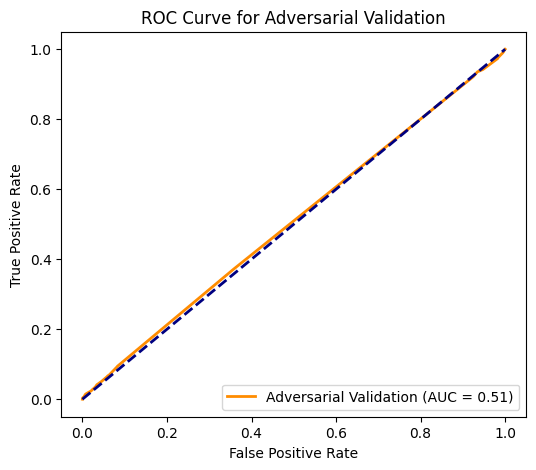

In [83]:
fpr, tpr, _ = roc_curve(y_va, preds)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Adversarial Validation (AUC = {auc_score:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Adversarial Validation')
plt.legend(loc="lower right")
plt.show()

2.3 特徴量選択の指標と手法

In [93]:
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns

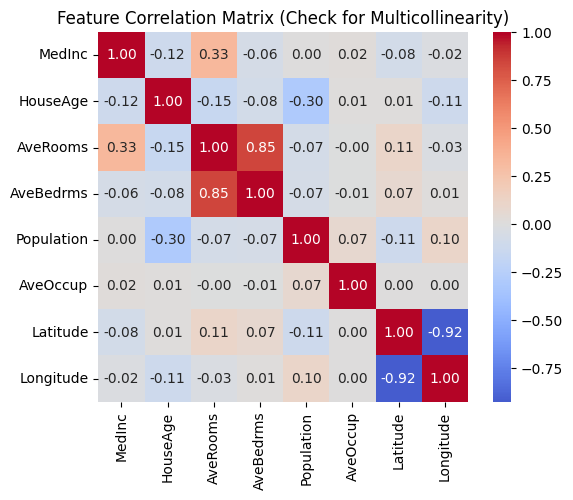

In [94]:
housing = fetch_california_housing(as_frame=True)
X = housing.data.copy()
corr_matrix = X.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix (Check for Multicollinearity)')
plt.show()

In [97]:
def calculate_vif(X):
    X_const = add_constant(X)
    vifs = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    
    # 3. 見やすくデータフレームにまとめる（'const'行は不要なので除外）
    df_vif = pd.DataFrame({'Feature': X_const.columns, 'VIF': vifs})
    df_vif = df_vif[df_vif['Feature'] != 'const'].sort_values(by='VIF', ascending=False)
    
    return df_vif

print(calculate_vif(X))

      Feature       VIF
7    Latitude  9.297624
8   Longitude  8.962263
3    AveRooms  8.342786
4   AveBedrms  6.994995
1      MedInc  2.501295
2    HouseAge  1.241254
5  Population  1.138125
6    AveOccup  1.008324


In [100]:
X_const = add_constant(X)
vifs = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vifs

[np.float64(17082.62369788156),
 np.float64(2.5012945125415973),
 np.float64(1.2412541182182888),
 np.float64(8.342785615374497),
 np.float64(6.994994771360948),
 np.float64(1.138125081833602),
 np.float64(1.0083244489804448),
 np.float64(9.297624369314345),
 np.float64(8.96226347381993)]

--- 特徴量選択 数理指標サマリー ---
            Pearson_r  Spearman_rho       VIF  Mutual_Information
Longitude   -0.045967     -0.069667  8.962263            0.400147
MedInc       0.688075      0.676778  2.501295            0.387097
Latitude    -0.144160     -0.165739  9.297624            0.370763
AveRooms     0.151948      0.263367  8.342786            0.102874
AveOccup    -0.023737     -0.256594  1.008324            0.072716
HouseAge     0.105623      0.074855  1.241254            0.033368
AveBedrms   -0.046701     -0.125187  6.994995            0.024149
Population  -0.024650      0.003839  1.138125            0.020878


消す対象になる

In [101]:
def calculate_mi(X, y):
    mi_scores = mutual_info_regression(X, y, random_state=42)
    df_mi = pd.DataFrame({
        'Feature': X.columns,
        'MI_Score': mi_scores
    }).sort_values(by='MI_Score', ascending=False)
    
    return df_mi

y = housing.target  # 目的変数（住宅価格）を必ず渡す

# 計算と表示
df_mi_result = calculate_mi(X, y)
print(df_mi_result.to_string(index=False))

   Feature  MI_Score
 Longitude  0.400147
    MedInc  0.387097
  Latitude  0.370763
  AveRooms  0.102874
  AveOccup  0.072716
  HouseAge  0.033368
 AveBedrms  0.024149
Population  0.020878
